In [11]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import EvalCallback


class Projectile1DEnv(gym.Env):
    def __init__(self, max_x=200.0, max_steps=1, tol=1.0, min_angle=10.0, max_angle=80.0, max_v=80.0):
        super().__init__()
        self.g = 9.81
        self.min_angle = float(min_angle)
        self.max_angle = float(max_angle)        
        self.max_v = float(max_v)                
        self.max_x = float(max_x)
        self.max_steps = int(max_steps)
        self.tol = float(tol)  

        # State: normalized remaining distance in [-1, 1]
        self.observation_space = gym.spaces.Box(
            low=-1.0, high=1.0, shape=(1,), dtype=np.float32
        )
        # Actions: angle, velocity in [-1, 1] scaled to [min_angle,max_angle] and [0,max_v]
        self.action_space = gym.spaces.Box(
            low=-1.0, high=1.0, shape=(2,), dtype=np.float32
        )

        self.current_step = 0
        self.x0 = 0.0
        self.xt = 0.0
        self.remaining = 0.0

    def _range(self, angle_deg, v):
        return (v**2) * np.sin(2.0 * np.deg2rad(angle_deg)) / self.g
    
    def _obs(self):
        # clamp to [-1, 1] relative to a sensible bound
        return np.array([np.clip(self.remaining / self.max_x, -1.0, 1.0)], dtype=np.float32)
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        rng = np.random.default_rng(seed)
        self.x0 = rng.uniform(0, 20)
        self.xt = rng.uniform(self.x0 + 5, min(self.x0 + 150, self.x0 + self.max_x))
        self.remaining = self.xt - self.x0
        self.current_step = 0
        return self._obs(), {}

    def step(self, action):
        self.current_step += 1

        # Scale actions
        a = float(action[0])
        u = float(action[1])
        angle = self.min_angle + 0.5 * (a + 1.0) * (self.max_angle - self.min_angle)  # [min_angle, max_angle]
        v     = 0.5 * (u + 1.0) * self.max_v                                          # [0, max_v]

        R = self._range(angle, v)
        prev_gap = abs(self.remaining)
        self.remaining -= R
        new_gap = abs(self.remaining)

        # Dense reward: closeness + improvement, small step penalty
        reward = - new_gap / self.max_x + 0.5 * (prev_gap - new_gap) / self.max_x - 0.01

        terminated = new_gap <= self.tol
        if terminated:
            reward += 1.0  # success bonus

        truncated = self.current_step >= self.max_steps

        obs = self._obs()
        info = {
            "gap": new_gap,
            "angle_deg": angle,
            "velocity": v,
            "target_total": float(self.xt - self.x0),
            "remaining_signed": float(self.remaining),
        }
        return obs, float(reward), terminated, truncated, info

# -------------------------------
# Train the RL agent
# -------------------------------
env = Projectile1DEnv(max_steps=1, tol=1.0)
eval_env = Projectile1DEnv(max_steps=1, tol=1.0)
model = SAC(
    "MlpPolicy", env,
    gamma=1.0,                     # single step
    learning_rate=3e-4,
    buffer_size=100_000,
    batch_size=256,
    ent_coef="auto",
    target_entropy=-2,             # action_dim = 2
    train_freq=(1, "episode"),     # update per episode
    gradient_steps=64,             # do several SGD steps
    learning_starts=1_000,
    tensorboard_log="./sac_log/",
    verbose=1,
)

cb = EvalCallback(eval_env, eval_freq=5_000, n_eval_episodes=200, deterministic=True, best_model_save_path="./sac_log/best")
model.learn(total_timesteps=30, callback=cb, tb_log_name="Projectile1DRun")


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./sac_log/Projectile1DRun_6
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | -0.856   |
| time/              |          |
|    episodes        | 4        |
|    fps             | 101      |
|    time_elapsed    | 0        |
|    total_timesteps | 4        |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | -1.23    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 93       |
|    time_elapsed    | 0        |
|    total_timesteps | 8        |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | -1.03    |
| time/              |          |
|    episodes    

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | -0.783   |
| time/              |          |
|    episodes        | 20       |
|    fps             | 89       |
|    time_elapsed    | 0        |
|    total_timesteps | 20       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | -0.771   |
| time/              |          |
|    episodes        | 24       |
|    fps             | 95       |
|    time_elapsed    | 0        |
|    total_timesteps | 24       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | -0.726   |
| time/              |          |
|    episodes        | 28       |
|    fps             | 97       |
|    time_elapsed    | 0        |
|    total_timesteps | 28       |
--------------

In [ ]:
# -------------------------------
# Test the trained model
# -------------------------------
obs = np.array([90 / 200], dtype=np.float32)
action, _ = model.predict(obs, deterministic=True)

# Rescale to real units
angle_deg = (action[0] + 1) / 2 * env.max_angle
velocity = (action[1] + 1) / 2 * env.max_v

print(f"Predicted: Angle = {angle_deg:.2f}°, Velocity = {velocity:.2f} m/s")

Predicted: Angle = 39.28°, Velocity = 28.20 m/s


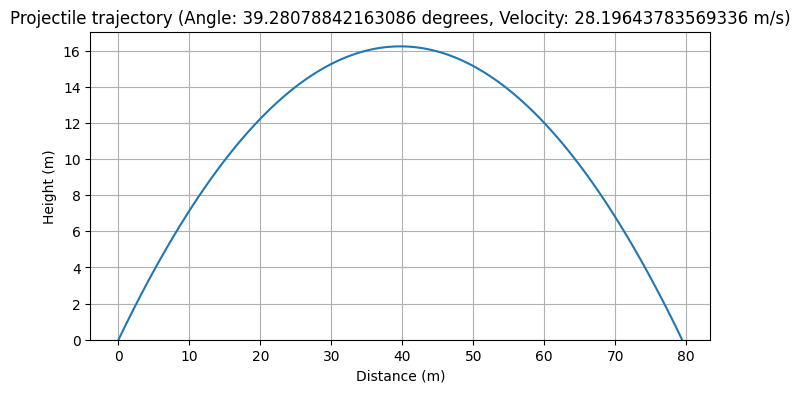

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_projectile(angle_deg, velocity, gravity=9.81):
    angle_rad = np.radians(angle_deg)
    
    # Calculate time of flight
    time_of_flight = 2 * velocity * np.sin(angle_rad) / gravity

    # Calculate time points
    t = np.linspace(0, time_of_flight, num=100)
    
    # Calculate x and y positions
    x = velocity * np.cos(angle_rad) * t
    y = velocity * np.sin(angle_rad) * t - 0.5 * gravity * t**2

    # Plot
    plt.figure(figsize=(8,4))
    plt.plot(x, y)
    plt.title(f"Projectile trajectory (Angle: {angle_deg} degrees, Velocity: {velocity} m/s)")
    plt.xlabel("Distance (m)")
    plt.ylabel("Height (m)")
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.show()

# Example usage:
plot_projectile(angle_deg, velocity)

In [ ]:
gym.make("")